In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor

# NOTE: Replaced sklearn Pipeline + OrdinalEncoder + RandomForest with CatBoostRegressor.
# Brand stays a true categorical (native CatBoost cat_features) — no label encoding.

In [2]:
df = pd.read_csv('data/mobile_price_prediction.csv')
df

,Brand,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,"LG V30+ (Black, 128 )",4.3,4.0,128.0,6.00,48,13.0,4000,24999
1,I Kall K11,3.4,6.0,64.0,4.50,48,12.0,4000,15999
2,Nokia 105 ss,4.3,4.0,4.0,4.50,64,16.0,4000,15000
3,"Samsung Galaxy A50 (White, 64 )",4.4,6.0,64.0,6.40,48,15.0,3800,18999
4,"POCO F1 (Steel Blue, 128 )",4.5,6.0,128.0,6.18,35,15.0,3800,18999
...,...,...,...,...,...,...,...,...,...
831,Karbonn K24 Plus Pro,3.8,6.0,32.0,4.54,48,12.0,2800,1299
832,InFocus POWER 2,4.1,8.0,64.0,4.54,64,NaN,2500,1390
833,"Alcatel 5V (Spectrum Blue, 32 )",4.4,3.0,32.0,6.20,48,1.0,3800,9790
834,JIVI JV 12M,3.7,10.0,32.0,4.50,64,NaN,3500,799


In [3]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (836, 9)

Data types:
Brand             object
Ratings          float64
RAM              float64
ROM              float64
Mobile_Size      float64
Primary_Cam        int64
Selfi_Cam        float64
Battery_Power      int64
Price              int64
dtype: object

Missing values:
Brand              0
Ratings           31
RAM                7
ROM                4
Mobile_Size        2
Primary_Cam        0
Selfi_Cam        269
Battery_Power      0
Price              0
dtype: int64


In [4]:
df.describe()

,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
count,805.000000,829.000000,832.000000,834.000000,836.000000,567.000000,836.000000,836.00000
mean,4.103106,6.066345,64.373077,5.597282,47.983254,9.784832,3274.688995,18220.34689
std,0.365356,2.530336,53.447825,3.898664,11.170093,6.503838,927.518852,52805.55022
min,2.800000,0.000000,0.000000,2.000000,5.000000,0.000000,1020.000000,479.00000
25%,3.800000,6.000000,32.000000,4.500000,48.000000,5.000000,3000.000000,984.75000
50%,4.100000,6.000000,40.000000,4.770000,48.000000,8.000000,3000.000000,1697.00000
75%,4.400000,6.000000,64.000000,6.300000,48.000000,13.000000,3800.000000,18999.00000
max,4.800000,34.000000,256.000000,44.000000,64.000000,61.000000,6000.000000,573000.00000


In [5]:
# Filling missing values (no target leakage: never use Price to impute feature columns)
# Numerical → median; Brand → mode if missing (EDA-friendly before Brand tokenization in next cells)
num_cols_eda = df.select_dtypes(include=[np.number]).columns
for col in num_cols_eda:
    df[col] = df[col].fillna(df[col].median())
if df["Brand"].isna().any():
    df["Brand"] = df["Brand"].fillna(df["Brand"].mode().iloc[0])


In [6]:
#Removing Outliers
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

print("\nAfter Outlier Removal Shape:", df.shape)



After Outlier Removal Shape: (774, 9)


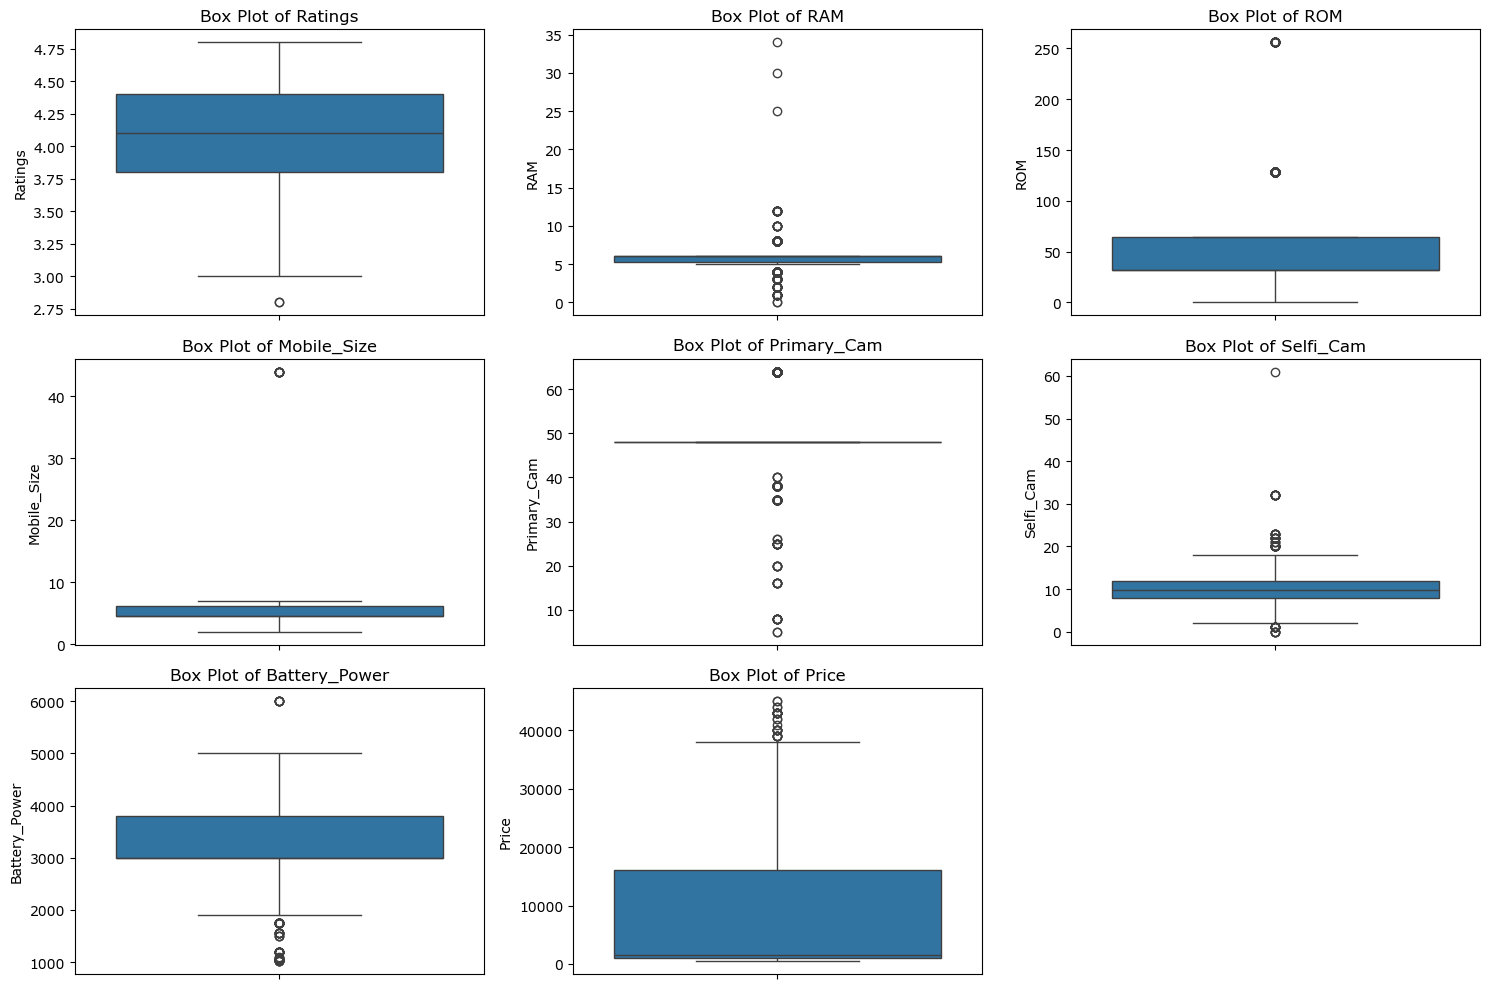

In [7]:
#Boxplots
numerical_features = ['Ratings', 'RAM', 'ROM', 'Mobile_Size', 'Primary_Cam', 'Selfi_Cam', 'Battery_Power','Price']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

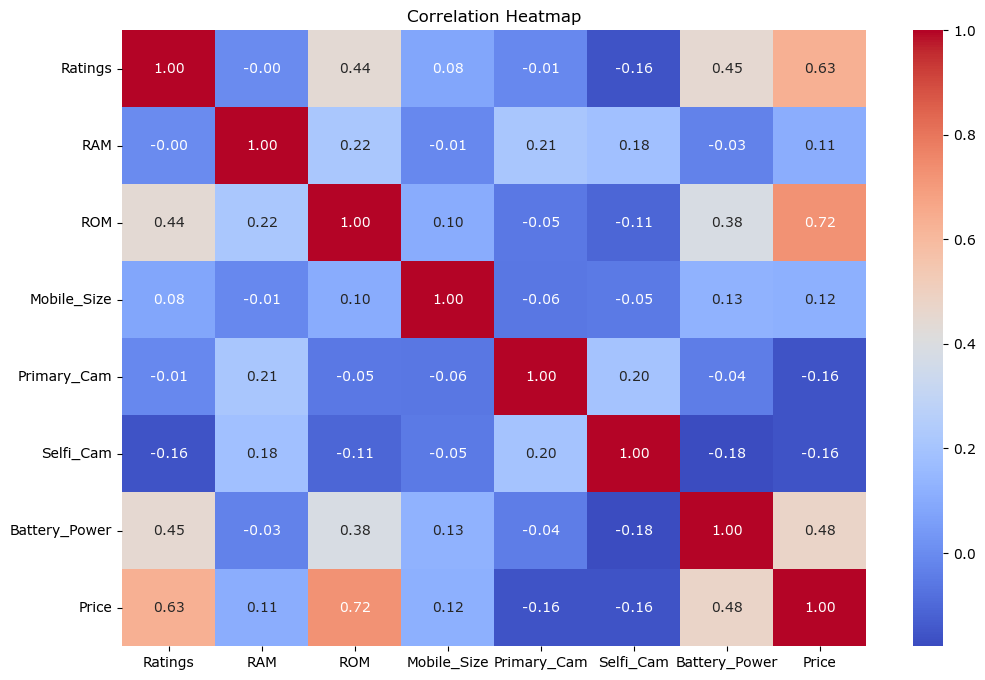

In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

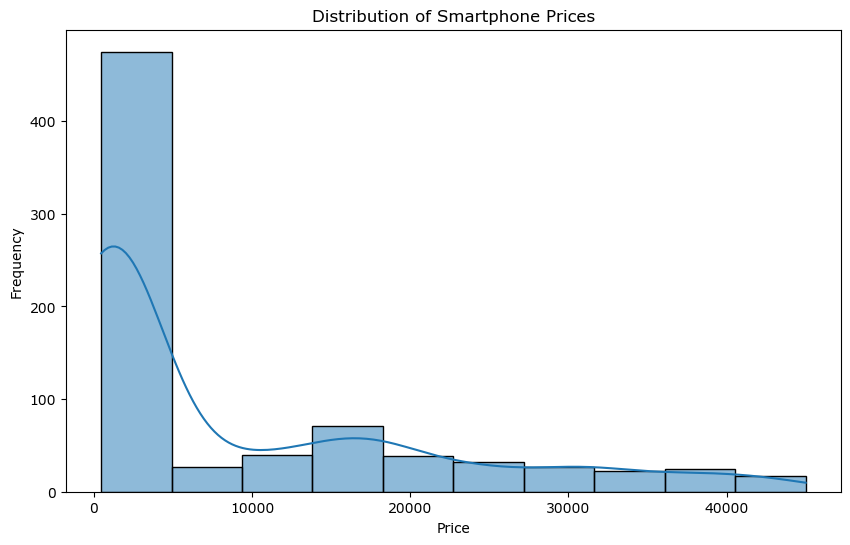

In [18]:
# Distribution of target variable (Price)
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=10, kde=True)
plt.title('Distribution of Smartphone Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

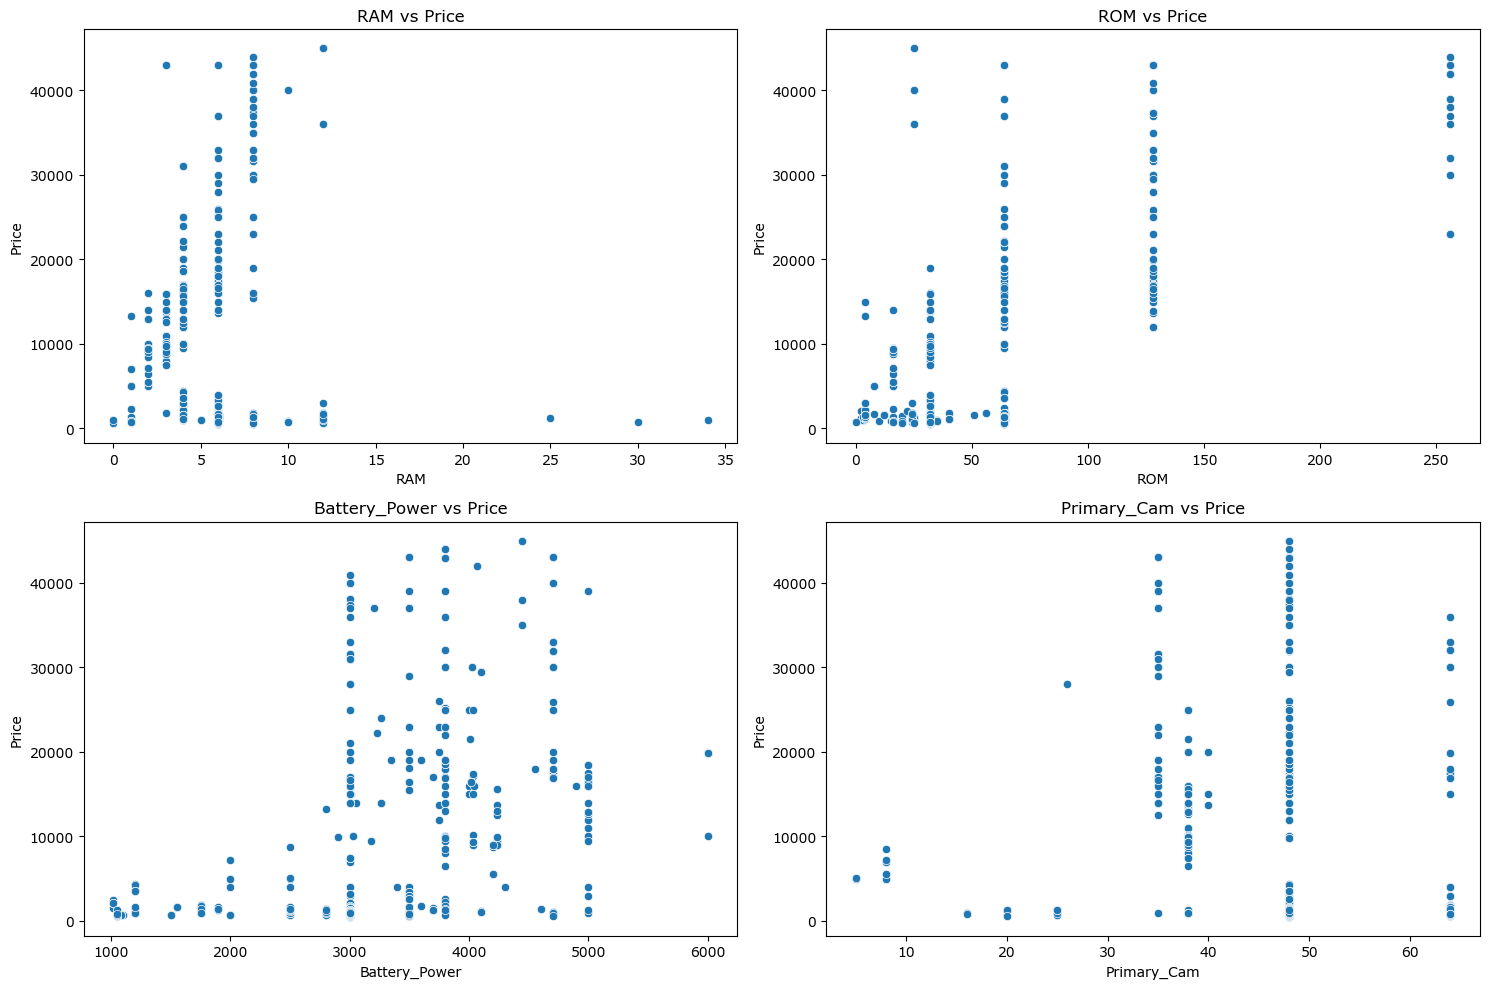

In [20]:
key_features = ['RAM', 'ROM', 'Battery_Power', 'Primary_Cam']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(key_features):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=df[feature], y=df['Price'])
    plt.title(f'{feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
plt.tight_layout()
plt.show()

C:\Users\Sambram\AppData\Local\Temp\ipykernel_7500\2653753728.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Brand'] = df['Brand'].str.split().str[0]



Top Brands by Ratings:
 Brand
Infinix     4.600000
OnePlus     4.517647
Google      4.500000
Motorola    4.500000
Apple       4.500000
POCO        4.500000
Realme      4.500000
Redmi       4.472414
Forme       4.450000
Vivo        4.405000
Name: Ratings, dtype: float64


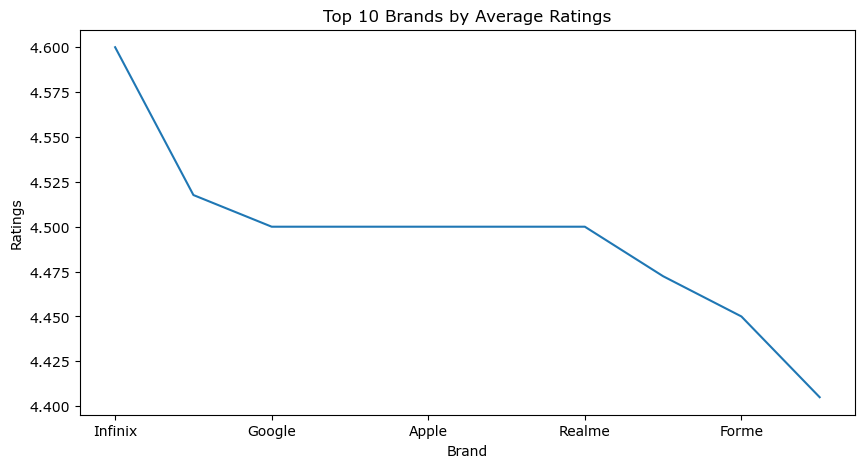

In [11]:
df['Brand'] = df['Brand'].str.split().str[0]

# Average rating per brand
brand_rating = df.groupby('Brand')['Ratings'].mean().sort_values(ascending=False)

print("\nTop Brands by Ratings:\n", brand_rating.head(10))

# Plot
plt.figure(figsize=(10,5))
brand_rating.head(10).plot(kind='line')
plt.title("Top 10 Brands by Average Ratings")
plt.ylabel("Ratings")
plt.show()

In [ ]:
# --- Feature engineering (additive; uses only inputs, not Price - avoids target leakage) ---
# performance_score: joint "capability" signal from RAM, camera, and battery
df["performance_score"] = df["RAM"] * np.sqrt(df["Primary_Cam"]) + df["Battery_Power"] / 500.0
# value_index: spec density vs display size (larger screens often cost more; this captures specs/screen tradeoff)
df["value_index"] = (df["RAM"] * df["ROM"]) / (df["Mobile_Size"] ** 2 + 0.1)


In [12]:
# --- Modelling (CatBoost + categorical Brand) ---
TARGET = "Price"
FEATURE_COLS = [
    "Brand", "Ratings", "RAM", "ROM", "Mobile_Size",
    "Primary_Cam", "Selfi_Cam", "Battery_Power",
    "performance_score", "value_index",
]
CAT_FEATURES = ["Brand"]  # native categorical - learns brand premium vs same specs


def impute_train_test(X_train: pd.DataFrame, X_test: pd.DataFrame):
    """Impute from train only: median (numeric), mode (Brand). Reduces leakage vs global fill."""
    X_train = X_train.copy()
    X_test = X_test.copy()
    num_cols = [c for c in X_train.columns if c not in CAT_FEATURES]
    for c in num_cols:
        med = X_train[c].median()
        X_train[c] = X_train[c].fillna(med)
        X_test[c] = X_test[c].fillna(med)
    mode = X_train["Brand"].mode()
    brand_fill = mode.iloc[0] if len(mode) else "unknown"
    X_train["Brand"] = X_train["Brand"].fillna(brand_fill).astype(str)
    X_test["Brand"] = X_test["Brand"].fillna(brand_fill).astype(str)
    return X_train, X_test


X = df[FEATURE_COLS].copy()
y = df[TARGET]


In [13]:
# 80/20 train-test; validation split from train for early stopping (not from test set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_test = impute_train_test(X_train, X_test)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=80,
    allow_writing_files=False,
)
cat_model.fit(
    X_tr,
    y_tr,
    cat_features=CAT_FEATURES,
    eval_set=(X_val, y_val),
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [14]:
# Pickle dict so Flask can load CatBoost without sklearn Pipeline; backend applies same feature engineering
artifact = {
    "model": cat_model,
    "cat_features": CAT_FEATURES,
    "feature_cols": FEATURE_COLS,
}
joblib.dump(artifact, "mobile_price_pipeline.pkl")
print("Saved mobile_price_pipeline.pkl (CatBoostRegressor + categorical Brand)")

Model Saved


In [15]:
# Evaluation on held-out 20% test set
y_pred = cat_model.predict(X_test)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2 = float(r2_score(y_test, y_pred))
print("========== Test metrics (20% holdout) ==========")
print(f"RMSE: {rmse:,.2f}")
print(f"R^2:  {r2:.4f}")
print("================================================")

0.8756581123588034

In [16]:
# Training-set fit (sanity check; not used for model selection)
y_pred_train = cat_model.predict(X_train)
print(
    "Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)),
    "| Train R^2:", r2_score(y_train, y_pred_train),
)

Accuracy Score :  87.56581123588035 %


         Feature  Importance
3            ROM    0.547310
0          Brand    0.218397
1        Ratings    0.107246
2            RAM    0.055558
5    Primary_Cam    0.028880
7  Battery_Power    0.021536
6      Selfi_Cam    0.014600
4    Mobile_Size    0.006474


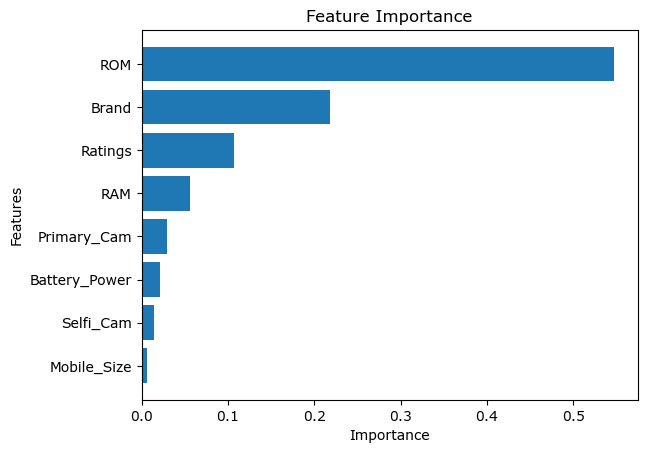

In [17]:
# Explainability: CatBoost built-in feature importance (high mean target change / splits)
feat_imp = pd.DataFrame({
    "Feature": cat_model.feature_names_,
    "Importance": cat_model.feature_importances_,
}).sort_values("Importance", ascending=False)

print(feat_imp.to_string(index=False))

brand_rows = feat_imp[feat_imp["Feature"] == "Brand"]
if len(brand_rows):
    b_imp = brand_rows["Importance"].iloc[0]
    pct = 100.0 * b_imp / feat_imp["Importance"].sum()
    print(f"\n>>> Brand importance: {b_imp:.4f} (~{pct:.1f}% of total normalized importance)")

plt.figure(figsize=(9, 5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"], color="#22d3ee")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost feature importance (includes brand premium signal)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()